# MPW2 - Computational graphs

In [49]:
import random
import pandas as pd
import numpy as np
from numpy.linalg import inv
import matplotlib.pyplot as plt
from cgnodes import *

In this notebook, spot the **TO_COMPLETE** comments in the code and in the markdown cells. Don't hesitate to add your own code and markdown cells to complete the exercises. You can also add comments in the code to explain your reasoning.

## 1. Simple computational graph framework

Let's do a simple test with the available computational graph framework. The function to compute is $f = (x_1 x_2)^2$

![Simple computational graph](../images/simple-graph-1.jpg)

In [50]:
# first create all ValueNode objects
x1 = ValueNode()
x2 = ValueNode()
q = ValueNode()
f = ValueNode()

# then create all <Operator>Node objects
mult = MultiplyNode(x1, x2, q)
square = SquareNode(q, f)

# finally build the graph by declaring inputs and outputs as 2 lists of ValueNode objects
cg = CompGraph([x1, x2], [f])

# test the graph with some random inputs
cg.forward([2.0, 4.0])
print(f"f = {f.v}")  # should print 64.0

f = 64.0


## 2. Get a dataset
### 2.1 Read data
We will use a simple dataset for this exercise with rent prices of appartments in Lausanne, as a function of the living area in square meters and the number of rooms. Define the path to the file containing the CSV data and read the data using Pandas.

In [51]:
datafile = "../data/lausanne-appart.csv"
dataset = pd.read_csv(datafile)
dataset.head()

,living_area,nb_rooms,rent_price
0,69,3.0,1810
1,95,3.5,2945
2,21,1.5,685
3,20,1.0,720
4,33,1.5,830


In [52]:
# get the data as numpy arrays for the rent price and the living area
rent_price = dataset.rent_price.values
living_area = dataset.living_area.values

### 2.2 Visualize the data
Plot a scatter plot of renting price as a function of living area

In [53]:
# in this function, x_curve and y_curve are the points of the model curve to plot (what the model estimates),
# they are optional. Theta_0, theta_1, theta_2 are the parameters of the model to display in the legend, 
# also optional.
def plot_data_prediction(
        x_points,
        y_points,
        x_curve=None,
        y_curve=None,
        x_title='x',
        y_title='y',
        theta_0=None,
        theta_1=None,
        theta_2=None):
    plt.title("{} as a function of {}".format(y_title, x_title))
    plt.xlabel(x_title)   # ex "Living area (m^2)"
    plt.ylabel(y_title)   # ex "Rent (CHF)"
    plt.scatter(x_points, y_points, label="data")
    model_label = "model"
    if theta_0 is not None and theta_1 is not None:
        model_label = fr"model ($\theta_0={theta_0:.3f}$, $\theta_1={theta_1:.3f}$)"
    if theta_0 is not None and theta_1 is not None and theta_2 is not None:
        model_label += fr", $\theta_2={theta_2:.3f}$)"
    if x_curve is not None and y_curve is not None:
        plt.plot(x_curve, y_curve, color="red", label=model_label)
    plt.legend()
    plt.grid(True)
    plt.show()

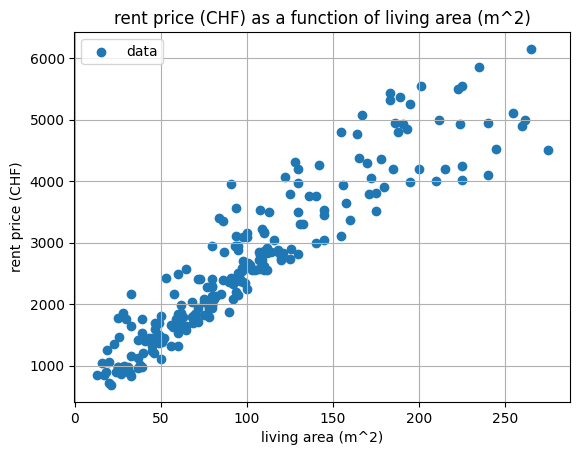

In [54]:
plot_data_prediction(living_area, rent_price, x_title='living area (m^2)', y_title='rent price (CHF)')

## 3. Normal equations for linear regression

The simplest regression model is a linear model defined with the parameters $\theta$ as follows:

\begin{equation*}
	\hat{y} = h_{\theta}(\mathbf{x}) = \theta_{0} + \theta_{1} x
\end{equation*}

We can find the optimal parameters $\theta$ for linear regression by minimizing the mean squared error (MSE) between the predicted values and the actual values. The MSE loss is given by:

\begin{equation*}
	J(\theta) = \frac{1}{2N} \sum_{n=1}^{N} (\hat{y}_{n} - y_{n})^{2}
\end{equation*}

This is a classical optimization problem that can be solved using calculus. The closed form solution to this problem is the following :

\begin{equation*}
	\theta = (X^{T}X)^{-1}X^{T}\vec{y}
\end{equation*}

intercept (theta_0): 657.6890591150313
slope (theta_1)    : 19.661179947454315


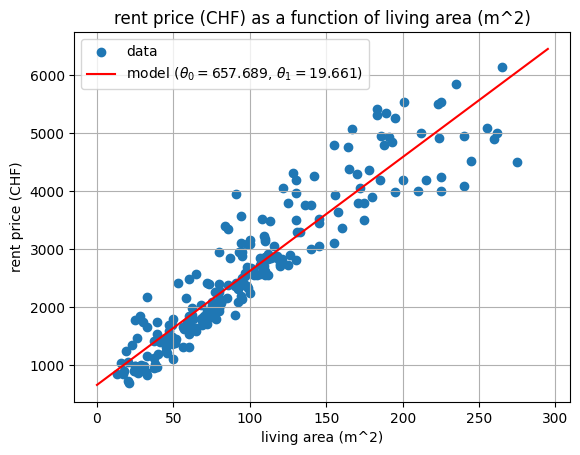

In [82]:
# see Eq. (3), (4) and (5) of the MPW2 pdf
X = np.c_[np.ones(len(living_area)), living_area]
y = rent_price

# TO COMPLETE
theta = np.linalg.inv(X.T @ X) @ X.T @ y
#

print("intercept (theta_0):", theta[0])  # should be around 658
print("slope (theta_1)    :", theta[1])  # should be around 19.7

x_curve = np.array(np.linspace(0, np.max(X) + 20, 200))
y_curve = theta[0] + theta[1] * x_curve

plot_data_prediction(
    living_area,
    rent_price,
    x_curve,
    y_curve,
    x_title='living area (m^2)',
    y_title='rent price (CHF)',
    theta_0=theta[0],
    theta_1=theta[1],
)

The values of $\theta_0$ and $\theta_1$ obtained above are your references for the rest of the exercises.
Parameter $\theta_1$ defines the slope, equal to the augmentation of the rent price for each additional square meter of living area. Parameter $\theta_0$ defines the intercept, equal to the rent price when the living area is zero. We can observe a price evolution of around 20 CHF per additional square meter ($\theta_1 = 19.7$).

b) Compute the overall MSE loss :

In [83]:
# TO COMPLETE
def mse_loss(y_hat, y):
    loss = np.sum((y_hat - y) ** 2) / (2 * len(y))
    return loss
#

y_hat = theta[0] + theta[1] * living_area
J = mse_loss(y_hat, y)
print("The total value of the loss is", J)  # should be around 105K

The total value of the loss is 104915.13056913581


This value is minimum with the optimal $\theta$. It is pretty large because the data is noisy and the model is very simple (linear regression). Another frequently used metric is the root mean squared error (RMSE) which is the square root of the MSE. It is in the same unit as the target variable and is easier to interpret. Other commonly used metrics are the mean absolute error (MAE) and the mean absolute percentage error (MAPE). MAE is the average of the absolute  differences between the predicted values and the actual values. It is also in the same unit as the target variable and is less sensitive to outliers than the MSE. MAPE is the average of the absolute percentage differences between the predicted values and the actual values. It is a relative error metric that is useful when the target variable has a wide range of values.

In [85]:
# TO COMPLETE
def rmse_loss(y_hat, y):
    loss = np.sqrt(np.mean((y_hat - y) ** 2))
    return loss

def mae_loss(y_hat, y):
    loss = np.mean(np.abs(y_hat - y))
    return loss

def mape_loss(y_hat, y):
    loss = np.mean(np.abs((y_hat - y) / y))
    return loss
#

rmse = rmse_loss(y_hat, y)
mae = mae_loss(y_hat, y)
mape = mape_loss(y_hat, y)
mape_percent = 100 * mape
print("The total value of the RMSE loss is", round(rmse))
print("The total value of the MAE loss is", round(mae))
print("The total value of the MAPE loss is", f"{mape_percent:.1f}%")

The total value of the RMSE loss is 458
The total value of the MAE loss is 347
The total value of the MAPE loss is 14.6%


TO COMPLETE : Implement the functions above to compute the MSE, RMSE, MAE and MAPE losses. Compute these losses for the linear regression model with the optimal $\theta$ obtained above. Interpret the results.
Extra question: What could be the problem with MAPE ?

**Answer:**
The linear model fit is not perfect. 

RMSE loss of 458 means that the mean prediction error is about 458 CHF. Since it squares the errors before averaging, it gives large mistakes more weight than smaller ones.

This is why with the exact same Model we get a MAE loss of 347, corresponding to an average error of 347 CHF. Since MAE just takes the mean of the absolut errors.

The difference in RMSE and MAE tells us that some apartments have large prediction errors, since as mentioned before RMSE penalizes large Mistakes. If every prediction error was about the same size the RMSE and MAE would be closer.

Example: <br>
Errors: 100, 100, 100, 100 <br>
**MAE = 100, RMSE = 100** <br>
Errors: 0, 0, 0, 400 <br>
**MAE = 100, but RMSE = 200**

**Extra Question:**
The Problem with MAPE is that it divides by the true value y. If a true value is 0, then the formula is undefined and if y is very small, MAPE can become extremely large and misleading.

## 4. Stochastic gradient descent for linear regression with computational graph

### 4.1 Graph creation

We need now to create a computational graph for the linear regression model and the MSE loss. The graph should have the following structure:

![Linear regression computational graph](../images/linear-regression-graph.jpg)

Before creating the graph, you need to complete the Python code __cgnodes.py__ with a new operator node __MSELossNode(MetaNode)__ that computes the MSE loss between the predicted values and the actual values. The node should have two inputs: the predicted values and the actual values. The node should have one output: the MSE loss.

Then you can create the graph below.

In [58]:
### TO COMPLETE  - CREATE THE GRAPH ###
# first create all ValueNode objects
theta_0 = ValueNode()
theta_1 = ValueNode()
x = ValueNode()
y = ValueNode()

q = ValueNode()
y_hat = ValueNode()
j = ValueNode()

# then create all <Operator>Node objects
mult = MultiplyNode(theta_1, x, q)
add = AddNode([theta_0, q], y_hat)
mse = MSELossNode(y_hat, y, j)

# finally build the graph by declaring inputs and outputs as 2 lists of ValueNode objects
cg = CompGraph([x, theta_0, theta_1, y], [j])

In [59]:
# try a forward pass with dummy values
cg.reset_values()
cg.forward([0.0, 0.0, 0.0, 1.0])
print(j.v)  # should give 0.5

0.5


In [60]:
cg.backward()
print(theta_0.grad_v, theta_1.grad_v)  # should give -1.0 -0.0

-1.0 -0.0


### 4.2 Plain vanilla stochastic gradient descent

In [61]:
# this function plots the evolution of the loss and the parameters during training, as well 
# as the data points and the model curve at the end of training. The last value of the 
# evolution of theta_0 and theta_1 is used to plot the model curve.
def plot_training_log(loss_evolution, t0_evolution, t1_evolution, x, y):
    fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(10,7))
    fig.suptitle('Training log')
    ax1.plot(t0_evolution)
    ax1.set_title('theta 0')
    ax2.plot(t1_evolution)
    ax2.set_title('theta 1')
    ax3.plot(loss_evolution)
    ax3.set_title('loss')
    ax4.scatter(x, y, s=1.0)
    x_curve = np.array(np.linspace(np.min(x), np.max(x), 2))
    y_curve = t0_evolution[-1] + t1_evolution[-1] * x_curve  # use last value of evolution as thetas
    ax4.plot(x_curve, y_curve, color='red')
    ax4.set_title('points and model output')
    fig.tight_layout()

Complete the code below to implement the stochastic gradient descent algorithm for linear regression. Make sure you understand the code and the algorithm before completing it. We will bring incremental evolution to this code so make sure you understand each lines of it. The code is pretty straightforward, but you can ask for help if you have any questions. 

intercept (theta_0): 1.0084621761499335
slope (theta_1)    : 24.473780280169738
The total value of the loss is 163444.04510169444


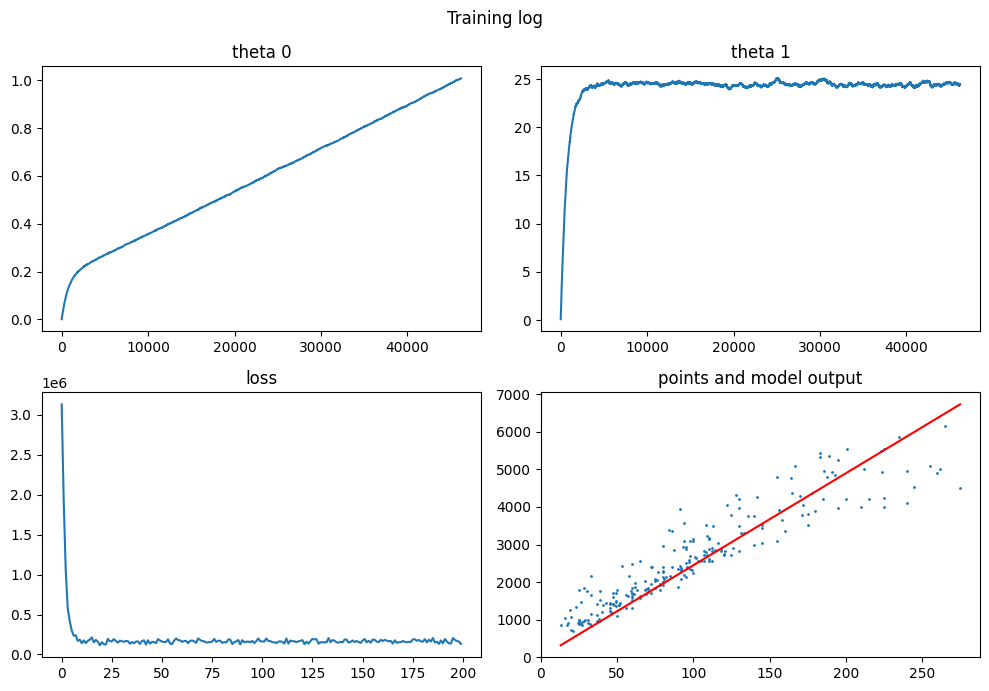

In [ ]:
alpha = 0.0000001     # learning rate
epochs = 200          # number of epochs (an epoch is a loop over the whole training set)
N = len(living_area)  # number of samples in the training set
t0 = 0.0              # initial value of theta_0
t1 = 0.0              # initial value of theta_1

loss_evolution = []  # to log the evolution of the loss
t0_evolution = []    # to log the evolution of theta_0
t1_evolution = []    # to log the evolution of theta_1

for epoch in range(epochs):
    n_steps = N
    epoch_loss = 0.0
    for step in range(n_steps):
        n = random.choice(range(0, N))  # random sampling in the training set
        cg.reset_values()
        cg.forward([living_area[n], t0, t1, rent_price[n]])
        cg.backward()
        t0 = t0 - alpha * theta_0.grad_v   # update rule for theta_0
        t1 = t1 - alpha * theta_1.grad_v  # update rule for theta_1
        epoch_loss += j.v
        t0_evolution.append(t0)
        t1_evolution.append(t1)
    loss_evolution.append(epoch_loss / n_steps)

print("intercept (theta_0):", t0)
print("slope (theta_1)    :", t1)
y_hat = t0 + t1 * living_area
J = mse_loss(y_hat, rent_price)
print("The total value of the loss is", J)
plot_training_log(loss_evolution, t0_evolution, t1_evolution, living_area, rent_price)

**Your observations** TO COMPLETE

- Evolution of the loss: The loss decreases fast during the first 15 epochs and then plateaus. The model gets close to optimal parameters early and then only does small adjustments. The single sample updates cause a not perfectly smooth curve and small fluctuations around the plateau.
- Evolution of theta_1: Converges quite quickly towards a stable value close to the minimum, but since we use a fixed learningrate it hoveres around the minimum rather than perfectly settling, the single sample updates also dont help.
- Evolution of theta_0: Converges slowly with minimal oscillation, indicating a stable learning rate. It has plateaued yet so we probably are not at the optimal value for theta_0 yet.


### 4.3 Batched gradient descent

Modify the code from the above stochastic gradient descent to implement a batched gradient descent algorithm. The idea is to compute the gradients on a batch of samples instead of a single sample. This can help to smooth the evolution of the parameters and the loss, and can also speed up the convergence.

intercept (theta_0): 0.46800522313360937
slope (theta_1)    : 24.443580441917405
The total value of the loss is 163568.6878767872


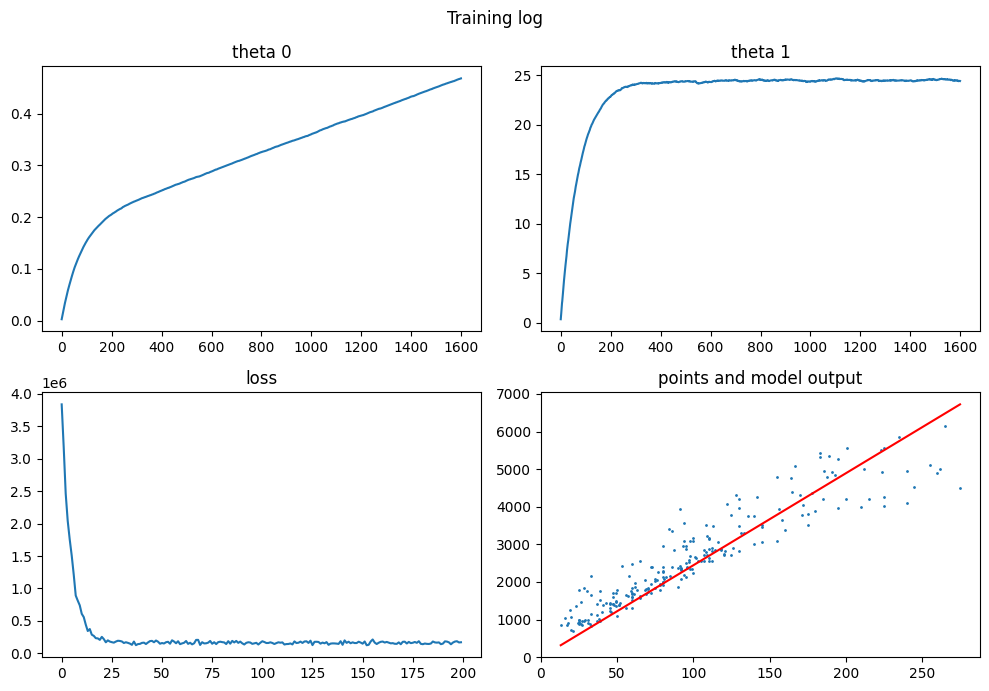

In [63]:
alpha = 0.000001  # learning rate can be higher than in the plain vanilla SGD 
                  # as we will average the gradients over a batch of samples
epochs = 200
batch_size = 32
N = len(living_area)
t0 = 0.0
t1 = 0.0

loss_evolution = []
t0_evolution = []
t1_evolution = []

for epoch in range(epochs):
    n_steps = N // batch_size + 1  # the number of batches to make 1 epoch
    epoch_loss = 0.0
    
    # TO COMPLETE
    for step in range(n_steps):
        
        grad_t0 = 0.0
        grad_t1 = 0.0
        batch_loss = 0.0

        for b in range(batch_size):
            n = random.choice(range(0, N))  
            cg.reset_values()
            cg.forward([living_area[n], t0, t1, rent_price[n]])
            cg.backward()

            grad_t0 += theta_0.grad_v
            grad_t1 += theta_1.grad_v
            batch_loss += j.v

        t0 = t0 - alpha * (grad_t0 / batch_size)
        t1 = t1 - alpha * (grad_t1 / batch_size)

        epoch_loss += batch_loss / batch_size
        t0_evolution.append(t0)
        t1_evolution.append(t1)

    loss_evolution.append(epoch_loss / n_steps)
    epoch_loss = 0.0

print("intercept (theta_0):", t0)
print("slope (theta_1)    :", t1)
y_hat = t0 + t1 * living_area
J = mse_loss(y_hat, rent_price)
print("The total value of the loss is", J)
plot_training_log(loss_evolution, t0_evolution, t1_evolution, living_area, rent_price)

**Your observations** TO COMPLETE

- Evolution of theta_0 and theta_1: theta_1 increases very quickly at the beginning and then stabilizes around a nearly constant value, we also got rid of most of the oscillation. theta_0 again increases more slowly and has not converged yet within the 200 epochs.
- Do we still have the same observation as in the plain stochastic version regarding the convergence of theta_1 and the slow evolution of theta_0 ? Yes, theta_1 converges much faster than theta_0. Batched gradient descent makes the evolution smoother and less noisy, but theta_0 still evoles much slower.
- Can we use larger learning rates than in the plain stochastic version ? Yes we can, since the gradients are averaged over a batch of samples, the updates are more stable and less noisy, that is why we can use larger learning rates than with plain stochastic gradient descent.


## 5. Optimizers
### 5.1 Idea 1: use different learning rates for $\theta_0$ and $\theta_1$

This is a very simple idea that can help to speed up the convergence of $\theta_0$ and $\theta_1$. We can use a larger learning rate for $\theta_1$ than for $\theta_0$ as $\theta_1$ converges faster than $\theta_0$. This idea is actually a first step towards RMSProp which is an optimizer that uses different learning rates for different parameters based on the history of the gradients.

intercept (theta_0): 653.3826458614583
slope (theta_1)    : 19.399057727737382
The total value of the loss is 105493.02932156013


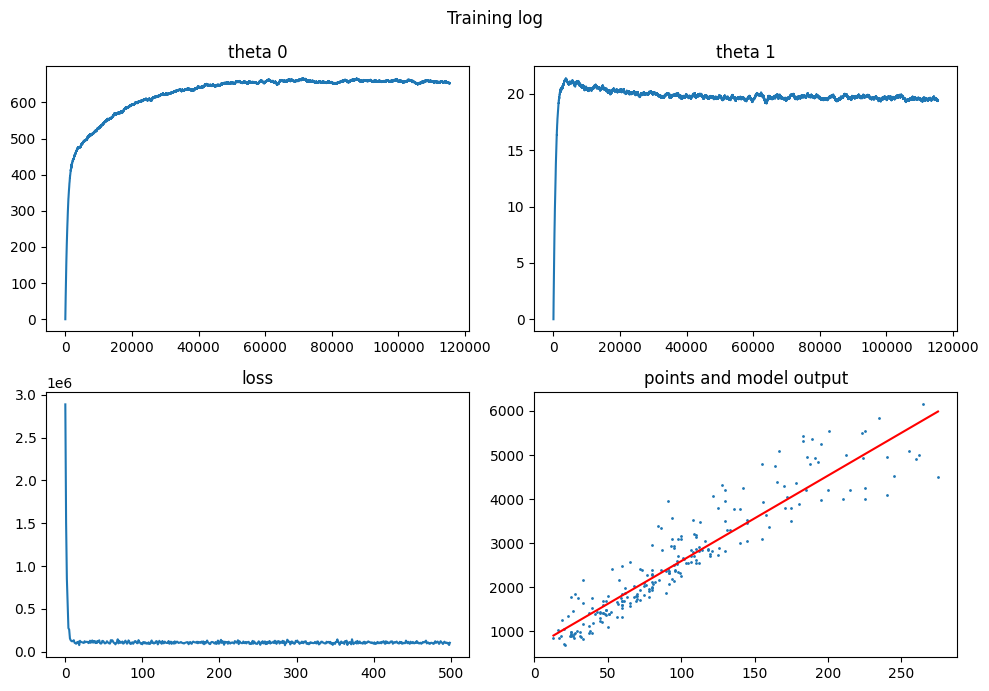

In [64]:
alpha_t0 = 0.00025    # learning rate for theta_0
alpha_t1 = 0.0000001  # learning rate for theta_1
epochs = 500          # number of epochs (an epoch is a loop over the whole training set)

# TO COMPLETE
N = len(living_area)  # number of samples in the training set
t0 = 0.0              # initial value of theta_0
t1 = 0.0              # initial value of theta_1

loss_evolution = []   # to log the evolution of the loss
t0_evolution = []     # to log the evolution of theta_0
t1_evolution = []     # to log the evolution of theta_1

for epoch in range(epochs):
    n_steps = N
    epoch_loss = 0.0
    for step in range(n_steps):
        n = random.choice(range(0, N))  # random sampling in the training set
        cg.reset_values()
        cg.forward([living_area[n], t0, t1, rent_price[n]])
        cg.backward()

        t0 = t0 - alpha_t0 * theta_0.grad_v
        t1 = t1 - alpha_t1 * theta_1.grad_v

        epoch_loss += j.v
        t0_evolution.append(t0)
        t1_evolution.append(t1)

    loss_evolution.append(epoch_loss / n_steps)

print("intercept (theta_0):", t0)
print("slope (theta_1)    :", t1)
y_hat = t0 + t1 * living_area
J = mse_loss(y_hat, rent_price)
print("The total value of the loss is", J)
plot_training_log(loss_evolution, t0_evolution, t1_evolution, living_area, rent_price)

**Your observations**. TO COMPLETE

- Evolution of the loss: the loss drops very fast at the beginning and then stays low and stable, which indicates a good convergence of the model.
- Evolution of theta_1: theta_1 converges very quickly, slightly overshoots the optimum at the beginning, and then goes back down before fluctuating around a stable value close to the optimum.
- Evolution of theta_0: theta_0 increases very fast at the start and then flattens, showing a much faster convergence than in the last two experiments. It also finally reaches a plateau where we can say that it has approximately converged to a stable value close to the optimum, which ist 652 CHF.



### 5.2 Idea 2: accelerate the movement of the parameters with the principle of momentum

The idea is to accelerate the modification of the parameters introducing a memory about the previous evolutions of the gradients. If the gradients are always in the same direction, we can accelerate the movement of the parameter updates in that direction. This is done by introducing a new variable called *momentum* that accumulates the gradients over time, and using this variable to update the parameters instead of the current gradient. The analogy would be to think of a ball rolling down the hill of parameter space, accelerating when the successive values of the gradients are aligned. The classical momentum equations are the following:

\begin{equation*}
	m^{(t+1)} = \beta \cdot m^{(t)} + \alpha \cdot grad^{(t)}
\end{equation*}

\begin{equation*}
    \theta^{(t+1)} = \theta^{(t)} - m^{(t+1)}
\end{equation*}

The value $\beta$ is multiplying the previous momentum and controls how much inertia we inject in the system. Values of $\beta$ above $1.0$ will make the system diverge and overflow. Too small $\beta$ value will not help if the way to the optimal value of the $\theta$ is far. A frequently used default is $\beta = 0.9$, but this is a value that needs to be tuned for each specific problem.

In our previous experiments, the parameter $\theta_0$ has gradients that seem to go always in the same direction. Convergence would benefit from this memory, accelerating the growth of $\theta_0$. This is less the case for $\theta_1$ which shows a quick convergence to a plateau, with gradients that are not always in the same direction. This is why we can expect a bigger improvement for $\theta_0$ than for $\theta_1$ with this idea. To handle this, we recommend to introduce two new variables `momentum_t0` and `momentum_t1` that accumulate the gradients of $\theta_0$ and $\theta_1$ respectively. We then use these momentum variables to update the parameters instead of the current gradients.

Complete the code below to implement the momentum optimizer for linear regression.

intercept (theta_0): 666.5030483722733
slope (theta_1)    : 19.616920834151177
The total value of the loss is 104928.59149386462


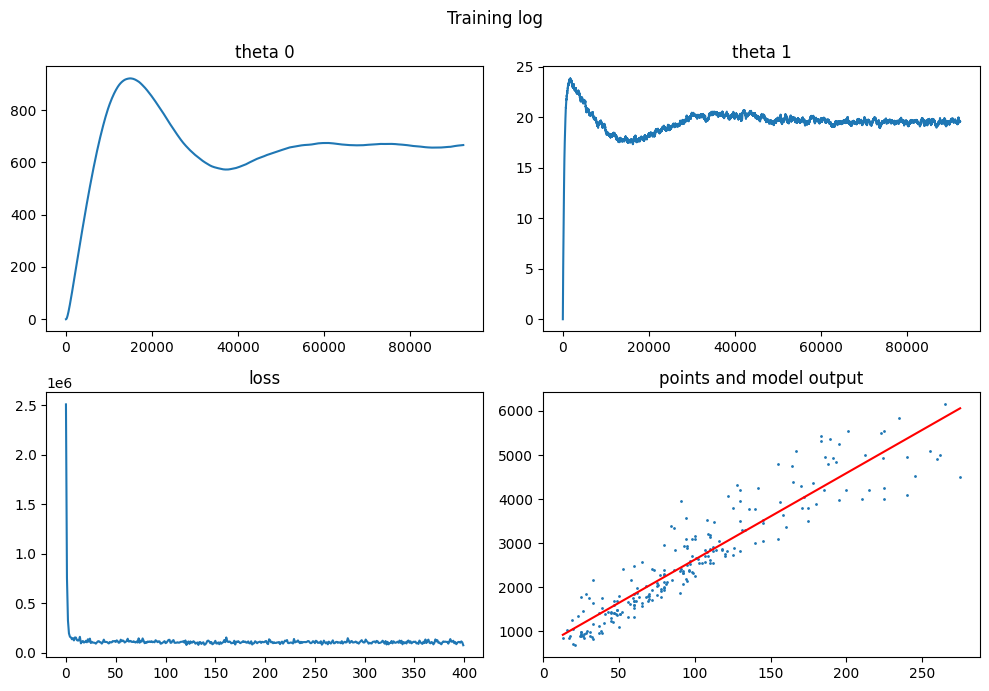

In [65]:
alpha = 0.0000001     # learning rate
beta_momentum_t0 = 0.9999     # momentum factor for theta_0
beta_momentum_t1 = 0.5000     # momentum factor for theta_1
epochs = 400          # number of epochs (an epoch is a loop over the whole training set)

# TO COMPLETE
N = len(living_area)  # number of samples in the training set
t0 = 0.0              # initial value of theta_0
t1 = 0.0              # initial value of theta_1
momentum_t0 = 0.0
momentum_t1 = 0.0

loss_evolution = []   # to log the evolution of the loss
t0_evolution = []     # to log the evolution of theta_0
t1_evolution = []     # to log the evolution of theta_1

for epoch in range(epochs):
    n_steps = N
    epoch_loss = 0.0

    for step in range(n_steps):
        n = random.choice(range(0, N))  # random sampling in the training set
        cg.reset_values()
        cg.forward([living_area[n], t0, t1, rent_price[n]])
        cg.backward()

        momentum_t0 = beta_momentum_t0 * momentum_t0 + alpha * theta_0.grad_v
        momentum_t1 = beta_momentum_t1 * momentum_t1 + alpha * theta_1.grad_v

        t0 = t0 - momentum_t0
        t1 = t1 - momentum_t1

        epoch_loss += j.v
        t0_evolution.append(t0)
        t1_evolution.append(t1)

    loss_evolution.append(epoch_loss / n_steps)

print("intercept (theta_0):", t0)
print("slope (theta_1)    :", t1)
y_hat = t0 + t1 * living_area
J = mse_loss(y_hat, rent_price)
print("The total value of the loss is", J)
plot_training_log(loss_evolution, t0_evolution, t1_evolution, living_area, rent_price)


**TO COMPLETE:** <br>
Momentum clearly accelerates the learning, especially for theta_0, which befor was evolving very slowly. Here we can see that theta_0 moves much faster toward the optimum because the optimizer keeps a memory of the past gradients and continues pushing in the same direction. At the same time, this extra acceleration makes the parameter overshoot the optimum before coming back down and oscillating around it. It is very satisfying to see that the optimizer behaves almost exactly like the marble analogy used to explain momentum. The parameter rolls past the optimum, just like a marble rolling past the lowest point of a valley, then moves back and forth around it before gradually settling.


## Optional objectives

Pick at least 2 of the following optional objectives to further explore and analyze the performance of your models:

- Investigate the use of 2nd order model instead of the simple linear model.
- Re-implement and experiment with more advanced optimizers such as RMSProp, Nesterov or Adam.
- Implement an early stopping strategy in your training loop.
- Implement a \textit{Learning Rate Decay on Plateau} strategy in the training loop.
- Normalize the input data with a zero norm approach and compare to your experiments without normalization.


## Normalize the input data

We will normalize the data, mean = 0 and std = 1 and save it to a new variable called **living_area_norm**

In [66]:
# Normalize the input feature: zero mean, unit variance
living_area_mean = np.mean(living_area)
living_area_std = np.std(living_area)

living_area_norm = (living_area - living_area_mean) / living_area_std

print("mean of normalized input:", np.mean(living_area_norm))
print("std of normalized input :", np.std(living_area_norm))


mean of normalized input: 0.0
std of normalized input : 1.0


normalized intercept (theta_0): 2595.469995731852
normalized slope (theta_1)    : 1184.5050234132211
The total value of the normalized-data loss is 104919.21485691702


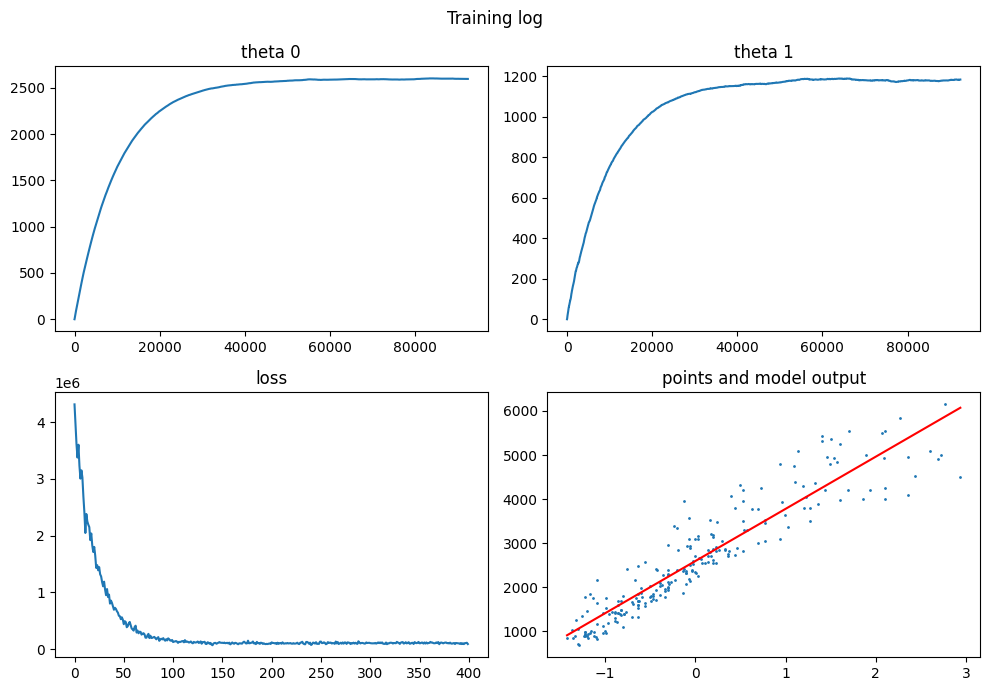

In [67]:
alpha = 0.00001    # learning rate
beta_momentum_t0 = 0.9     # momentum factor for theta_0
beta_momentum_t1 = 0.9    # momentum factor for theta_1
epochs_norm = 400        # number of epochs (an epoch is a loop over the whole training set)

N_norm = len(living_area_norm)
t0_norm = 0.0
t1_norm = 0.0
momentum_t0_norm = 0.0
momentum_t1_norm = 0.0

loss_evolution_norm = []
t0_evolution_norm = []
t1_evolution_norm = []

for epoch in range(epochs_norm):
    n_steps = N_norm
    epoch_loss_norm = 0.0

    for step in range(n_steps):
        n = random.choice(range(0, N_norm))
        cg.reset_values()
        cg.forward([living_area_norm[n], t0_norm, t1_norm, rent_price[n]])
        cg.backward()

        momentum_t0_norm = beta_momentum_t0 * momentum_t0_norm + alpha * theta_0.grad_v
        momentum_t1_norm = beta_momentum_t1 * momentum_t1_norm + alpha * theta_1.grad_v

        t0_norm = t0_norm - momentum_t0_norm
        t1_norm = t1_norm - momentum_t1_norm

        epoch_loss_norm += j.v
        t0_evolution_norm.append(t0_norm)
        t1_evolution_norm.append(t1_norm)

    loss_evolution_norm.append(epoch_loss_norm / n_steps)

print("normalized intercept (theta_0):", t0_norm)
print("normalized slope (theta_1)    :", t1_norm)

y_hat_norm = t0_norm + t1_norm * living_area_norm
J_norm = mse_loss(y_hat_norm, rent_price)
print("The total value of the normalized-data loss is", J_norm)

plot_training_log(
    loss_evolution_norm,
    t0_evolution_norm,
    t1_evolution_norm,
    living_area_norm,
    rent_price
)

Plot from 5.2 <br>
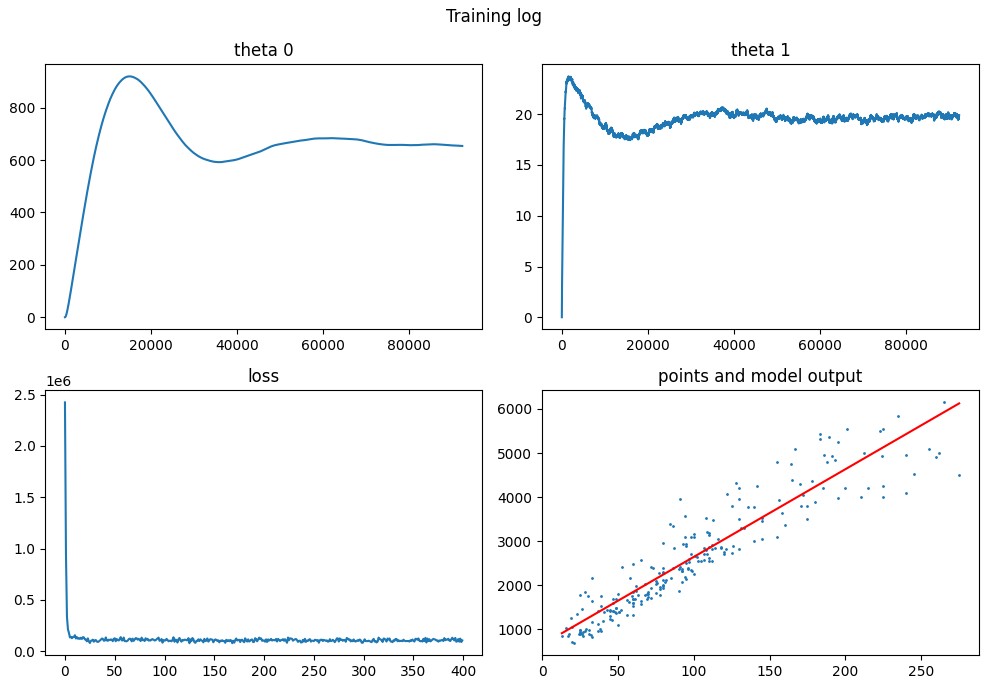

We can see that with normalization, the training becomes much smoother and more stable. In the non-normalized experiment, theta_0 and theta_1 show a clear overshoot and then oscillate before settling, whereas in the normalized experiment both parameters increase more steadily toward a plateau.

It is also important to mention, that in the normalized model, theta_0 no longer represents the rent when the living area is 0 m², because the normalized input is centered around zero, theta_0 now corresponds to the predicted rent for an apartment with average living area, which explains why it is close to the mean rent. Similarly, theta_1 is no longer the increase in rent per square meter, but the increase in rent for one standard deviation of living area.

I also had to adjust the hyperparameters because the learning rate and momentum values from before didnt work anymore, since normalization changes the scale of the input and also the scale of the gradients.

Normalization centers the data around zero and rescales it so that it has unit variance. This makes the input values more balanced, improves the conditioning of the optimization problem, and often helps gradient-based methods converge faster and more smoothly.


## Learning Rate Decay

intercept (theta_0): 533.5697246246469
slope (theta_1)    : 20.609233349897753
final alpha_t0     : 1e-08
final alpha_t1     : 1e-12
The total value of the loss is 107011.54341765688


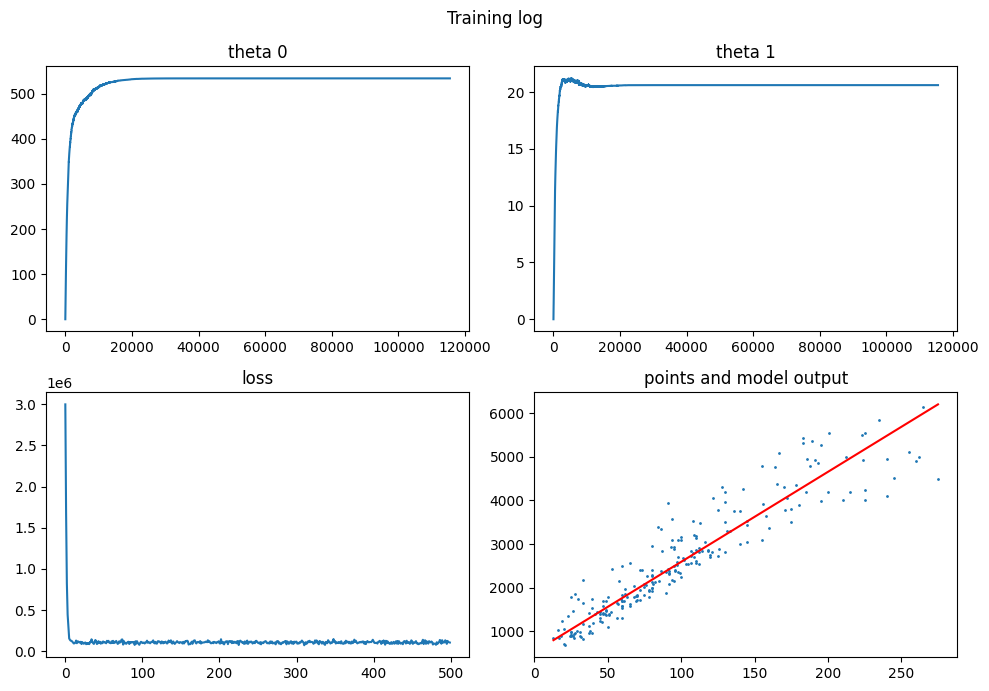

In [68]:
alpha_t0 = 0.00025    # learning rate for theta_0
alpha_t1 = 0.0000001  # learning rate for theta_1
epochs = 500          # number of epochs

# Decay Parameters
decay_factor = 0.5
patience = 10
min_alpha_t0 = 1e-8
min_alpha_t1 = 1e-12
improvement_threshold = 1e-3

N = len(living_area)
t0 = 0.0
t1 = 0.0

loss_evolution = []
t0_evolution = []
t1_evolution = []
alpha_t0_evolution = []
alpha_t1_evolution = []

best_loss = float("inf")
epochs_without_improvement = 0

for epoch in range(epochs):
    n_steps = N
    epoch_loss = 0.0

    for step in range(n_steps):
        n = random.choice(range(0, N))
        cg.reset_values()
        cg.forward([living_area[n], t0, t1, rent_price[n]])
        cg.backward()

        t0 = t0 - alpha_t0 * theta_0.grad_v
        t1 = t1 - alpha_t1 * theta_1.grad_v

        epoch_loss += j.v
        t0_evolution.append(t0)
        t1_evolution.append(t1)

    epoch_loss = epoch_loss / n_steps
    loss_evolution.append(epoch_loss)
    alpha_t0_evolution.append(alpha_t0)
    alpha_t1_evolution.append(alpha_t1)

    # Apply Learning Rate Decay
    if best_loss - epoch_loss > improvement_threshold:
        best_loss = epoch_loss
        epochs_without_improvement = 0
    else:
        epochs_without_improvement += 1

    if epochs_without_improvement >= patience:
        alpha_t0 = max(alpha_t0 * decay_factor, min_alpha_t0)
        alpha_t1 = max(alpha_t1 * decay_factor, min_alpha_t1)
        epochs_without_improvement = 0

print("intercept (theta_0):", t0)
print("slope (theta_1)    :", t1)
print("final alpha_t0     :", alpha_t0)
print("final alpha_t1     :", alpha_t1)

y_hat = t0 + t1 * living_area
J = mse_loss(y_hat, rent_price)
print("The total value of the loss is", J)

plot_training_log(loss_evolution, t0_evolution, t1_evolution, living_area, rent_price)


Plot from 5.1 <br>
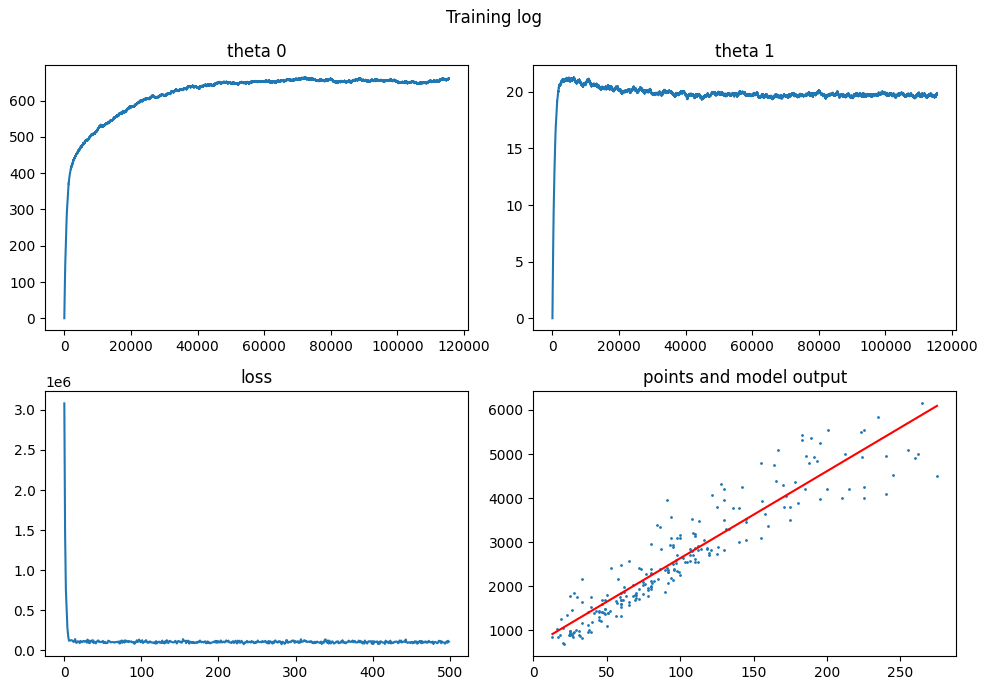

Compared with the result from 5.1, the version with learning rate decay converges more smoothly and stabilizes earlier. In 5.1, theta_0 continues to increase slowly for a long time and theta_1 also keeps drifting slightly before settling. With learning rate decay, both parameters reach a plateau earlier and show less movement later in training. The loss also becomes more stable once the optimizer is close to the optimum, because the updates become smaller.

We applied the weight decay by monitoring the average loss at the end of each epoch. If the loss does not improve enough for a certain number of epochs (`patience`), both learning rates are multiplied by a factor smaller than 1 (`decay_factor`). This means that training starts with relatively large updates to move quickly toward the optimum, and later switches to smaller updates to refine the parameters and reduce oscillations near the optimum.


## Early Stopping


Early stopping at epoch 42
intercept (theta_0): 516.1802383636605
slope (theta_1)    : 20.899004538787548
best epoch         : 27
best epoch loss    : 85327.81153315064
trained epochs     : 42
The total value of the loss is 107875.38862523036


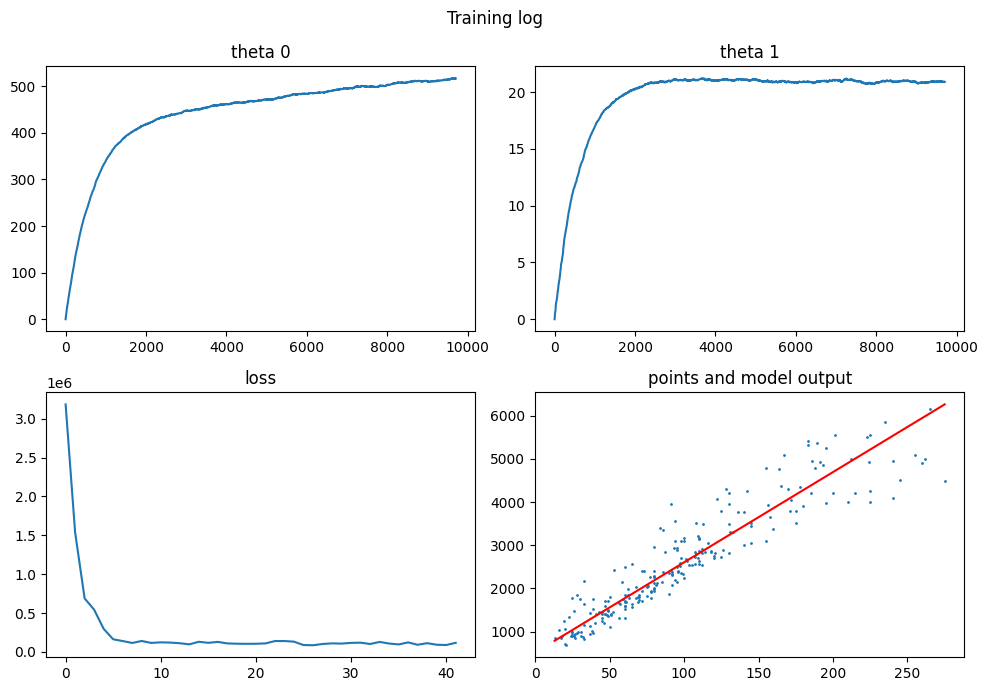

In [ ]:
alpha_t0 = 0.00025    # learning rate for theta_0
alpha_t1 = 0.0000001  # learning rate for theta_1
epochs = 500          # maximum number of epochs

# Early stopping parameters
patience = 15
improvement_threshold = 1e-3

N = len(living_area)
t0 = 0.0
t1 = 0.0

loss_evolution = []
t0_evolution = []
t1_evolution = []

best_loss = float("inf")
best_epoch = 0
epochs_without_improvement = 0
stopped_epoch = epochs

for epoch in range(epochs):
    n_steps = N
    epoch_loss = 0.0

    for step in range(n_steps):
        n = random.choice(range(0, N))
        cg.reset_values()
        cg.forward([living_area[n], t0, t1, rent_price[n]])
        cg.backward()

        t0 = t0 - alpha_t0 * theta_0.grad_v
        t1 = t1 - alpha_t1 * theta_1.grad_v

        epoch_loss += j.v
        t0_evolution.append(t0)
        t1_evolution.append(t1)

    epoch_loss = epoch_loss / n_steps
    loss_evolution.append(epoch_loss)

    # Early stopping decision mechanic:
    if best_loss - epoch_loss > improvement_threshold:
        best_loss = epoch_loss
        best_epoch = epoch + 1
        epochs_without_improvement = 0
    else:
        epochs_without_improvement += 1

    if epochs_without_improvement >= patience:
        stopped_epoch = epoch + 1
        print("Early stopping at epoch", stopped_epoch)
        break

print("intercept (theta_0):", t0)
print("slope (theta_1)    :", t1)
print("best epoch         :", best_epoch)
print("best epoch loss    :", best_loss)
print("trained epochs     :", stopped_epoch)

y_hat = t0 + t1 * living_area
J = mse_loss(y_hat, rent_price)
print("The total value of the loss is", J)

plot_training_log(loss_evolution, t0_evolution, t1_evolution, living_area, rent_price)


Plot from 5.1 <br>
![Plot from 5.1](../images/output.png)


Early stopping terminates the training process once the loss no longer improves significantly. In our implementation, we used:
- Patience: 15
- Improvement threshold: 1e-3.
This means that training is stopped if the loss does not decrease by more than the threshold (1e-3) over 15 consecutive epochs.

We base the early stopping model on the model from section 5.1, which uses different learning rates for $\theta_0$ and $\theta_1$, as it shows relatively fast convergence for both the parameters and a rapid decrease in the loss, followed by a prolonged plateau (especially for the loss). The results of this model suggest that early stopping may be beneficial.

In both cases (model from section 5.1 and early stopping model), the loss decreases rapidly at the beginning and reaches a similarly low value. However, with early stopping, training is terminated once further improvements become negligible, instead of continuing with many small updates

The MSE obtained by the early stopping model is relatively close to that of the optimal model (determined in section 3) and the model in section 5.1, being only slightly larger, which is expected when applying early stopping. Additionally $\theta_0$ does not seem to converge fully, stopping at approximately 516 compared to the optimal value of 658.

While training time is not a major concern for this simple model, the advantage of early stopping - especially for more complex models - is apparent, as comparable results are achieved in only around 40 epochs, compared to the 500 epochs required by the model in section 5.1.

## Different Optimizers

intercept (theta_0): 303.4303981294391
slope (theta_1)    : 22.379113561393083
The total value of the loss is 122007.83243895422


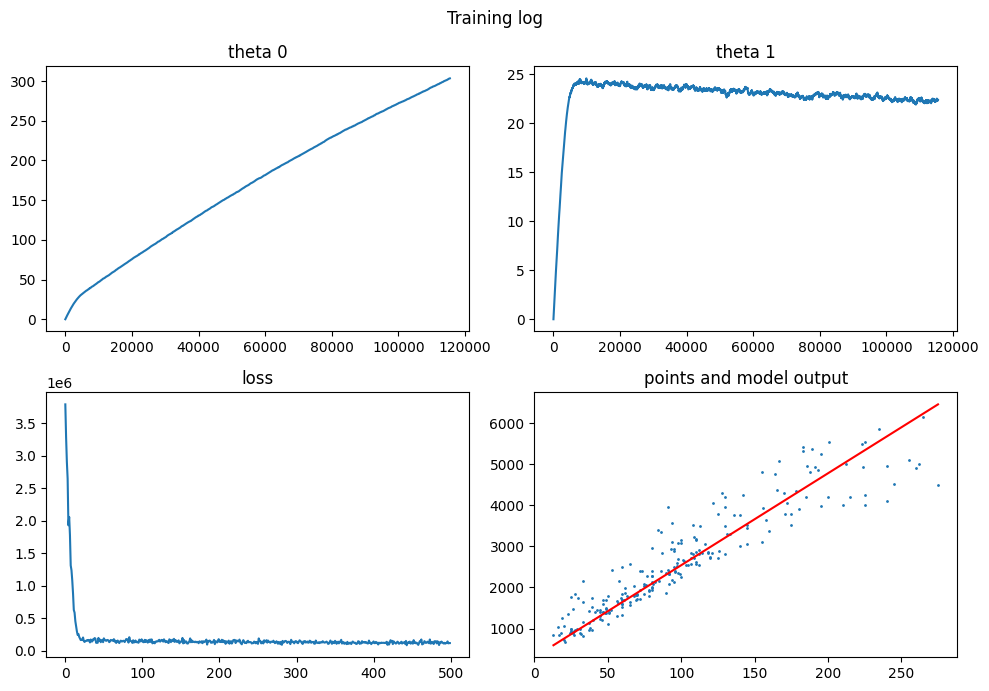

In [ ]:
alpha = 0.01          # learning rate for Adam
epochs = 500          # number of epochs

# Adam parameters
beta_momentum = 0.9   
beta_rmsprop = 0.999  
epsilon = 1e-8        

N = len(living_area)
t0 = 0.0
t1 = 0.0
momentum_t0 = 0.0
momentum_t1 = 0.0
squared_grad_t0 = 0.0
squared_grad_t1 = 0.0
step_count = 0

loss_evolution = []
t0_evolution = []
t1_evolution = []

for epoch in range(epochs):
    n_steps = N
    epoch_loss = 0.0

    for step in range(n_steps):
        n = random.choice(range(0, N))
        cg.reset_values()
        cg.forward([living_area[n], t0, t1, rent_price[n]])
        cg.backward()

        step_count += 1

        grad_t0 = theta_0.grad_v
        grad_t1 = theta_1.grad_v

        # Momentum:
        momentum_t0 = beta_momentum * momentum_t0 + (1 - beta_momentum) * grad_t0
        momentum_t1 = beta_momentum * momentum_t1 + (1 - beta_momentum) * grad_t1

        # RMSProp:
        squared_grad_t0 = beta_rmsprop * squared_grad_t0 + (1 - beta_rmsprop) * grad_t0**2
        squared_grad_t1 = beta_rmsprop * squared_grad_t1 + (1 - beta_rmsprop) * grad_t1**2

        # Bias correction:
        momentum_t0_corrected = momentum_t0 / (1 - beta_momentum**step_count)
        momentum_t1_corrected = momentum_t1 / (1 - beta_momentum**step_count)
        squared_grad_t0_corrected = squared_grad_t0 / (1 - beta_rmsprop**step_count)
        squared_grad_t1_corrected = squared_grad_t1 / (1 - beta_rmsprop**step_count)

        # Parameter update:
        t0 = t0 - alpha * momentum_t0_corrected / (np.sqrt(squared_grad_t0_corrected) + epsilon)
        t1 = t1 - alpha * momentum_t1_corrected / (np.sqrt(squared_grad_t1_corrected) + epsilon)

        epoch_loss += j.v
        t0_evolution.append(t0)
        t1_evolution.append(t1)

    loss_evolution.append(epoch_loss / n_steps)

print("intercept (theta_0):", t0)
print("slope (theta_1)    :", t1)
y_hat = t0 + t1 * living_area
J = mse_loss(y_hat, rent_price)
print("The total value of the loss is", J)
plot_training_log(loss_evolution, t0_evolution, t1_evolution, living_area, rent_price)


Plot from 5.2 <br>
![Plot from 5.2](../images/output2.png)

To evaluate the benefits of the Adam optimizer, we compare it to the model from 5.2 using momentum, since Adam builds directly on this idea.

The Adam model shows more stable parameter updates, e.g. reduced overshooting of the optimum, which probably comes from the RMSProp part of the optimizer. Updates appear better controlled, however, $\theta_0$ does not fully converge, while $\theta_1$ converges and plateaus relatively quickly.

Additionally, Adam requires careful tuning of the learning rate. Through trial and error, we determined:
- a = 0.1: Updates are too large. While $\theta_0$ converges, $\theta_1$ shows strong oscillations.
- a = 0.01: Provides the best trade-off. However, convergence is still not ideal, as $\theta_0$ does not fully stabilize.
- a = 0.001: Updates are too small, resulting in very slow progress, especially for $\theta_0$.

The optimizer appears to struggle with the scale of the data. Either $\theta_0$ does not converge, or, when it does, $\theta_1$ becomes very noisy. Therefore, we apply the model to the normalized data:

intercept (theta_0): 2591.6931400657013
slope (theta_1)    : 1186.9377633228826
The total value of the loss is 104931.09785294007


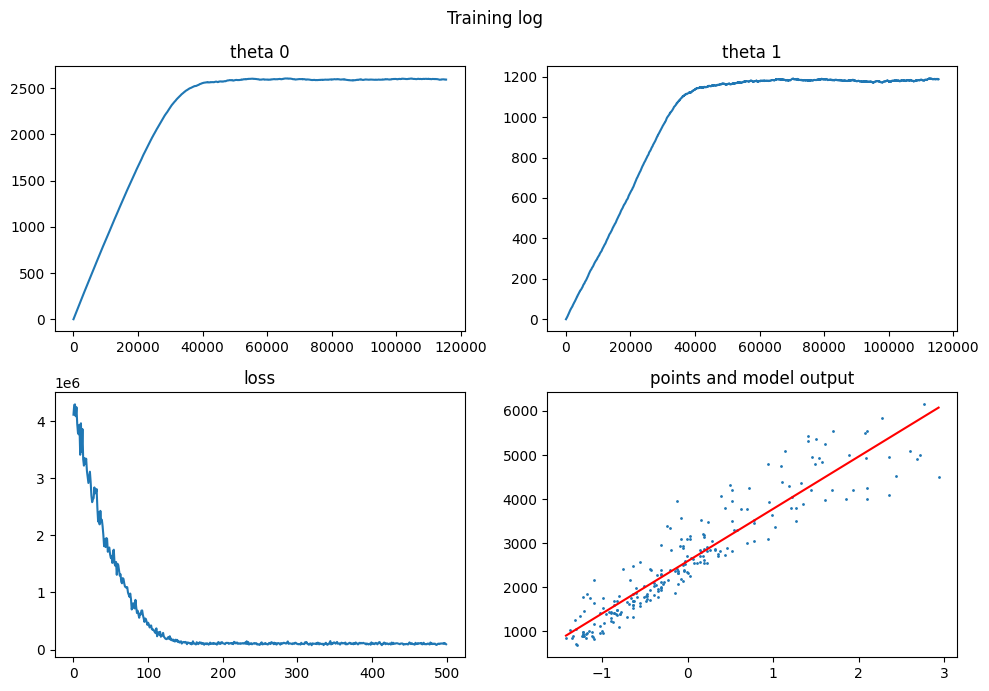

In [71]:
alpha = 0.1          # learning rate for Adam
epochs = 500          # number of epochs

# Adam parameters
beta_momentum = 0.9   
beta_rmsprop = 0.999  
epsilon = 1e-8        

N = len(living_area_norm)
t0 = 0.0
t1 = 0.0
momentum_t0 = 0.0
momentum_t1 = 0.0
squared_grad_t0 = 0.0
squared_grad_t1 = 0.0
step_count = 0

loss_evolution = []
t0_evolution = []
t1_evolution = []

for epoch in range(epochs):
    n_steps = N
    epoch_loss = 0.0

    for step in range(n_steps):
        n = random.choice(range(0, N))
        cg.reset_values()
        cg.forward([living_area_norm[n], t0, t1, rent_price[n]])
        cg.backward()

        step_count += 1

        grad_t0 = theta_0.grad_v
        grad_t1 = theta_1.grad_v

        # Momentum part: same principle as in 5.2, but with Adam's exponential average
        momentum_t0 = beta_momentum * momentum_t0 + (1 - beta_momentum) * grad_t0
        momentum_t1 = beta_momentum * momentum_t1 + (1 - beta_momentum) * grad_t1

        # RMSProp part: keeps memory of squared gradients to adapt the step size
        squared_grad_t0 = beta_rmsprop * squared_grad_t0 + (1 - beta_rmsprop) * grad_t0**2
        squared_grad_t1 = beta_rmsprop * squared_grad_t1 + (1 - beta_rmsprop) * grad_t1**2

        # Bias correction because both moving averages start at zero
        momentum_t0_corrected = momentum_t0 / (1 - beta_momentum**step_count)
        momentum_t1_corrected = momentum_t1 / (1 - beta_momentum**step_count)
        squared_grad_t0_corrected = squared_grad_t0 / (1 - beta_rmsprop**step_count)
        squared_grad_t1_corrected = squared_grad_t1 / (1 - beta_rmsprop**step_count)

        t0 = t0 - alpha * momentum_t0_corrected / (np.sqrt(squared_grad_t0_corrected) + epsilon)
        t1 = t1 - alpha * momentum_t1_corrected / (np.sqrt(squared_grad_t1_corrected) + epsilon)

        epoch_loss += j.v
        t0_evolution.append(t0)
        t1_evolution.append(t1)

    loss_evolution.append(epoch_loss / n_steps)

print("intercept (theta_0):", t0)
print("slope (theta_1)    :", t1)
y_hat = t0 + t1 * living_area_norm
J = mse_loss(y_hat, rent_price)
print("The total value of the loss is", J)
plot_training_log(loss_evolution, t0_evolution, t1_evolution, living_area_norm, rent_price)


For the normalized data, the behaviour of the Adam optimizer improves significantly.

With a learning rate of a = 0.1, the model converges well. Both $\theta_0$ and $\theta_1$ show a smooth trajectory and reach stable values without noticeable oscillations. Convergence appears much more controlled compared to using non-normalized data.

The loss decreases slightly noisy but reaches a stable plateau with only small fluctuations. However, convergence is slightly slower compared to both the non-normalized Adam case and the momentum-based model, and occurs only after around 130 epochs.

Since the mode is relatively simple, the advantages of Adam do not seem to fully come to fruition. While it avoids the overshooting observed in the momentum-based model, it appears to add unnecessary complexity, resulting in slower convergence - especially in the loss - while the momentum-based model focuses on fast convergence and seems sufficient for the task. In terms of MSE, both models achieve very similar performance.

## 2nd Order Model

In [72]:
# ValueNodes
theta_0 = ValueNode()
theta_1 = ValueNode()
theta_2 = ValueNode()
x = ValueNode()
y = ValueNode()

q1 = ValueNode()
q2 = ValueNode()
x_sq = ValueNode()
y_hat = ValueNode()
j = ValueNode()

# Operators
square = MultiplyNode(x, x, x_sq)                 # x^2
mult1 = MultiplyNode(theta_1, x, q1)              # theta1 * x
mult2 = MultiplyNode(theta_2, x_sq, q2)           # theta2 * x^2
add = AddNode([theta_0, q1, q2], y_hat)           # sum all
mse = MSELossNode(y_hat, y, j)

# Graph
cg = CompGraph([x, theta_0, theta_1, theta_2, y], [j])

The resulting model is:

\begin{equation*}
\hat{y} = \theta_{0} + \theta_{1} x + \theta_{2} x^{2}
\end{equation*}

In [73]:
# try a forward pass with dummy values
cg.reset_values()
cg.forward([0.0, 0.0, 0.0, 0.0, 1.0])
print(j.v)  # should give 0.5

0.5


In [74]:
cg.backward()
print(theta_0.grad_v, theta_1.grad_v, theta_2.grad_v)  # should give -2.0. -0.0 -0.0

-1.0 -0.0 -0.0


intercept (theta_0): 2723.440652844522
linear term (theta_1): 1289.0599883548512
quadratic term (theta_2): -128.8567457233434
The total value of the 2nd order model loss is 94103.66666159984


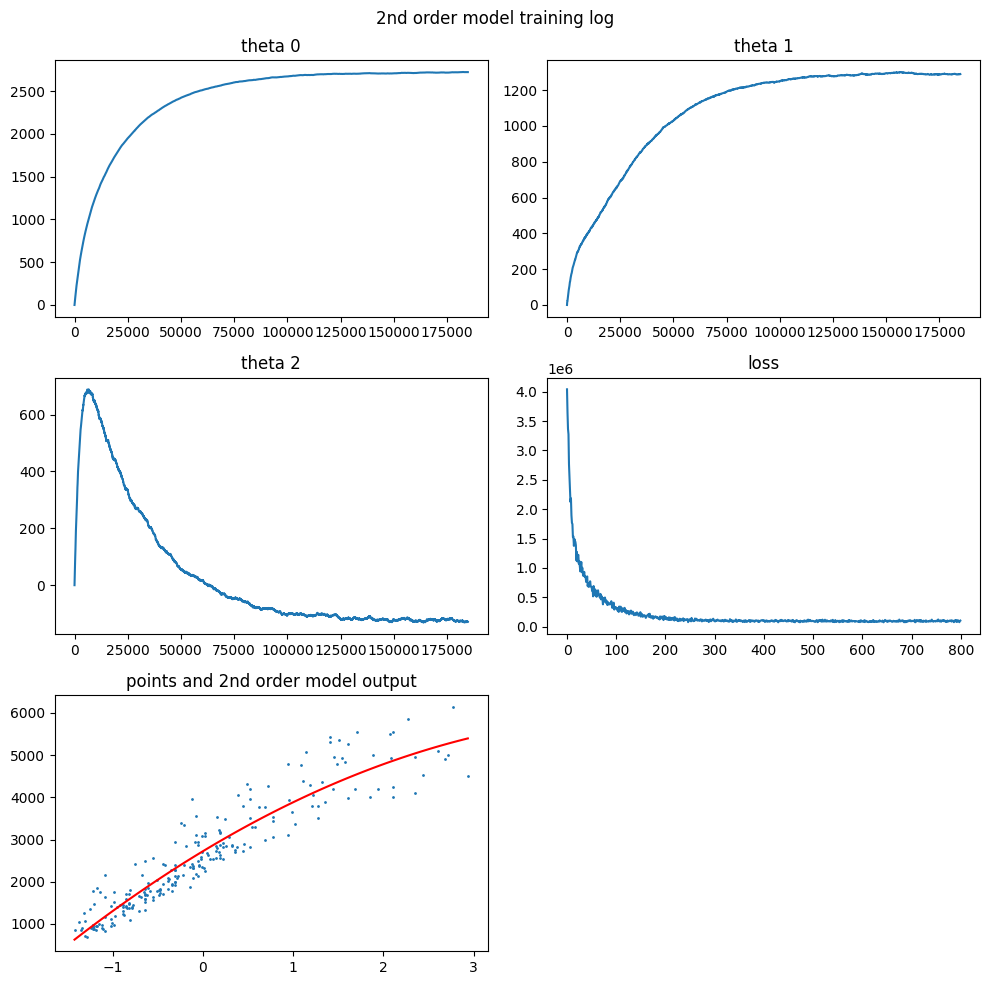

In [81]:
alpha = 0.00001      # learning rate
epochs = 800         # number of epochs

# Momentum parameters
beta_momentum_t0 = 0.9
beta_momentum_t1 = 0.9
beta_momentum_t2 = 0.9

N = len(living_area_norm)
t0 = 0.0
t1 = 0.0
t2 = 0.0

momentum_t0 = 0.0
momentum_t1 = 0.0
momentum_t2 = 0.0
loss_evolution = []
t0_evolution = []
t1_evolution = []
t2_evolution = []

for epoch in range(epochs):
    n_steps = N
    epoch_loss = 0.0

    for step in range(n_steps):
        n = random.choice(range(0, N))
        cg.reset_values()
        cg.forward([living_area_norm[n], t0, t1, t2, rent_price[n]])
        cg.backward()

        momentum_t0 = beta_momentum_t0 * momentum_t0 + alpha * theta_0.grad_v
        momentum_t1 = beta_momentum_t1 * momentum_t1 + alpha * theta_1.grad_v
        momentum_t2 = beta_momentum_t2 * momentum_t2 + alpha * theta_2.grad_v

        t0 = t0 - momentum_t0
        t1 = t1 - momentum_t1
        t2 = t2 - momentum_t2

        epoch_loss += j.v
        t0_evolution.append(t0)
        t1_evolution.append(t1)
        t2_evolution.append(t2)

    loss_evolution.append(epoch_loss / n_steps)

print("intercept (theta_0):", t0)
print("linear term (theta_1):", t1)
print("quadratic term (theta_2):", t2)

y_hat_2nd_order = t0 + t1 * living_area_norm + t2 * living_area_norm**2
J_2nd_order = mse_loss(y_hat_2nd_order, rent_price)
print("The total value of the 2nd order model loss is", J_2nd_order)

fig, ((ax1, ax2), (ax3, ax4), (ax5, ax6)) = plt.subplots(3, 2, figsize=(10, 10))
fig.suptitle('2nd order model training log')

ax1.plot(t0_evolution)
ax1.set_title('theta 0')
ax2.plot(t1_evolution)
ax2.set_title('theta 1')
ax3.plot(t2_evolution)
ax3.set_title('theta 2')
ax4.plot(loss_evolution)
ax4.set_title('loss')

ax5.scatter(living_area_norm, rent_price, s=1.0)
x_curve = np.linspace(np.min(living_area_norm), np.max(living_area_norm), 100)
y_curve = t0 + t1 * x_curve + t2 * x_curve**2
ax5.plot(x_curve, y_curve, color='red')
ax5.set_title('points and 2nd order model output')

ax6.axis('off')
fig.tight_layout()


The 2nd order model slightly improves the fit by allowing a small curvature in the prediction. However, since the relationship between living area and rent is already captured well by the linear model, the additional quadratic term provides only limited benefit.

Initially, the parameter $\theta_2$ increases and later decreases again, converging at a slightly negative value. The probable reason for this behaviour is that the optimizer initially increases $\theta_2$ to reduce loss quickly. Later as training progresses, $\theta_0$ and $\theta_1$ capture the main linear trend, and a large quadratic term is no longer necessary.

The resulting model shows a slight downward curvature. This indicates that rent increases steadily with living area, but the rate of increase becomes slightly smaller for large apartments.

Overall, the 2nd order model increases flexibility, but at the cost of added complexity and reduced interpretability, while only providing a marginal improvement over the linear model.